<a href="https://colab.research.google.com/github/OdehDan/MRI-Classification/blob/main/MRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Enter your Kaggle API token: ")

Enter your Kaggle API token: ··········


In [ ]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 820.1 kB/s eta 0:00:00


In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --unzip -p /content/brain_tumor

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:08<00:00, 18.9MB/s]



In [ ]:
import os

print(os.listdir("/content/brain_tumor"))

['Testing', 'Training']


In [ ]:
# I dentifying the train and test path
train_path = "/content/brain_tumor/Training"
test_path = "/content/brain_tumor/Testing"

for folder, path in [("Training", train_path), ("Testing", test_path)]:
    print(f"\n{folder}:")
    total = 0

    for class_name in sorted(os.listdir(path)):
        class_path = os.path.join(path, class_name)
        count = len(os.listdir(class_path))
        total += count
        print(f"{class_name}: {count}")

    print(f"Total {folder} images: {total}")


Training:
glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400
Total Training images: 5600

Testing:
glioma: 400
meningioma: 400
notumor: 400
pituitary: 400
Total Testing images: 1600


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet50, ResNet50_Weights,
    vgg16, VGG16_Weights,
    mobilenet_v2, MobileNet_V2_Weights,
    densenet121, DenseNet121_Weights,
    alexnet, AlexNet_Weights
)

In [ ]:
# Data augumentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
from torch.utils.data import random_split
full_dataset = datasets.ImageFolder(
    root=train_path
)

train_size = int(0.7 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_indices, val_indices = random_split(
    range(len(full_dataset)),
    [train_size, val_size]
)

train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=train_path,
    transform=val_transform
)

train_subset = torch.utils.data.Subset(
    train_dataset,
    train_indices
)

val_subset = torch.utils.data.Subset(
    val_dataset,
    val_indices
)

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False
)

test_dataset = datasets.ImageFolder(root=test_path, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
print(f"Classes : {train_dataset.classes}")
print(f"Traning samples : {train_size} images")
print(f"Validation samples : {val_size} images")
print(f"Test samples : {len(test_dataset)} images")

Classes : ['glioma', 'meningioma', 'notumor', 'pituitary']
Traning samples : 3919 images
Validation samples : 1681 images
Test samples : 1600 images


In [ ]:
images, labels = next(iter(train_loader))
images_display = images * 0.5 + 0.5

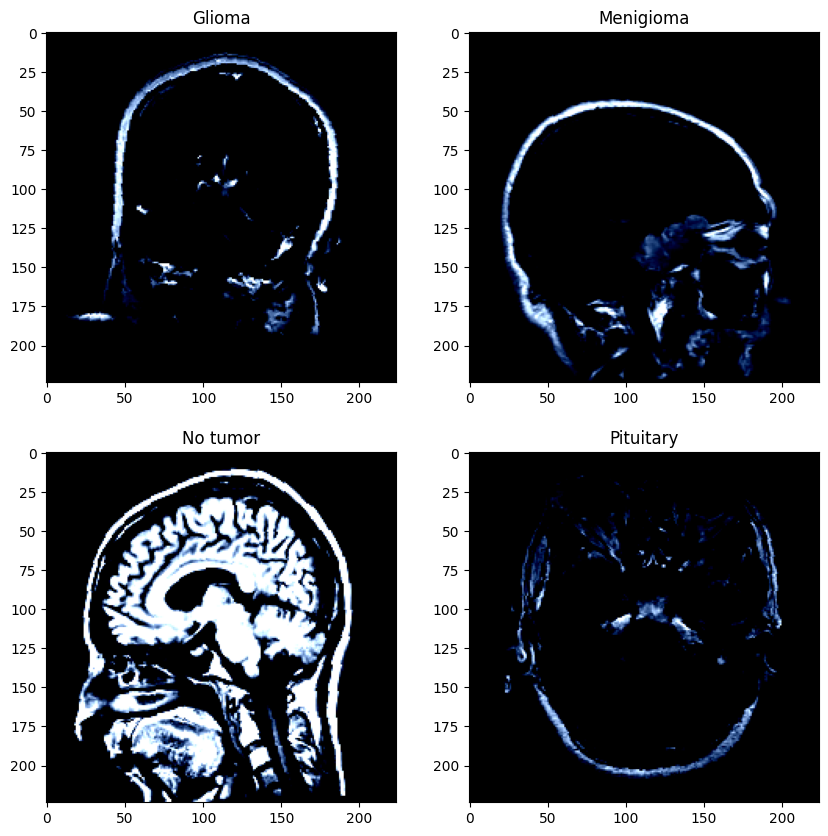

In [ ]:
# @title Slide to explore examples { run: "auto" }
glioma_idx = (labels==0).nonzero(as_tuple=True)[0]
menigioma_idx = (labels==1).nonzero(as_tuple=True)[0]
notumor_idx = (labels==2).nonzero(as_tuple=True)[0]
pituitary_idx = (labels==3).nonzero(as_tuple=True)[0]

idx_glioma = 2 #@param {type:"slider", min:0, max:12, step:1}
idx_menigioma = 3 #@param {type:"slider", min:0, max:12, step:1}
idx_notumor = 4 #@param {type:"slider", min:0, max:12, step:1}
idx_pituitary = 3 #@param {type:"slider", min:0, max:12, step:1}

glioma_img = images[glioma_idx[idx_glioma]].permute(1, 2, 0).numpy()
menigioma_img = images[menigioma_idx[idx_menigioma]].permute(1, 2, 0).numpy()
notumor_img = images[notumor_idx[idx_notumor]].permute(1, 2, 0).numpy()
pituitary_img = images[pituitary_idx[idx_pituitary]].permute(1, 2, 0).numpy()

plt.figure(figsize=(10,10))
plt.subplot(2, 2, 1)
plt.imshow(glioma_img)
plt.title("Glioma")
plt.grid(False)

plt.subplot(2, 2, 2)
plt.imshow(menigioma_img)
plt.title("Menigioma")
plt.grid(False)

plt.subplot(2, 2, 3)
plt.imshow(notumor_img)
plt.title("No tumor")
plt.grid(False)

plt.subplot(2, 2, 4)
plt.imshow(pituitary_img)
plt.title("Pituitary")
plt.grid(False)

plt.show()

In [ ]:
def make_pretrained_classifier(arch_name, n_outputs=4):
  if arch_name == "efficientnet_b0":
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, n_outputs)
  elif arch_name == "resnet50":
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, n_outputs)
  elif arch_name == "vgg16":
    model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, n_outputs)
  elif arch_name == "mobilenet_v2":
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, n_outputs)
  elif arch_name == "densenet121":
    model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, n_outputs)
  elif arch_name == "alexnet":
    model = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, n_outputs)
  else:
    raise ValueError(f"Unknown architecture: {arch_name}")
  return model.to(device)

Starting fresh

Training efficientnet_b0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 193MB/s]
efficientnet_b0 Epoch 1/10: 100%|██████████| 123/123 [00:36<00:00,  3.33it/s]


Epoch 1/10 - Avg Loss: 0.5333444264724971
✅ Best model saved (Val Loss = 0.1969)
Epoch 1/10 | Train Loss: 0.5333 | Val Loss: 0.1969 | LR: 1.00e-04


efficientnet_b0 Epoch 2/10: 100%|██████████| 123/123 [00:35<00:00,  3.43it/s]


Epoch 2/10 - Avg Loss: 0.18520490213380597
✅ Best model saved (Val Loss = 0.0909)
Epoch 2/10 | Train Loss: 0.1852 | Val Loss: 0.0909 | LR: 1.00e-04


...

Epoch 8/10 - Avg Loss: 0.029437262908464705
✅ Best model saved (Val Loss = 0.0310)
Epoch 8/10 | Train Loss: 0.0294 | Val Loss: 0.0315 | LR: 1.00e-04


efficientnet_b0 Epoch 9/10: 100%|██████████| 123/123 [00:37<00:00,  3.31it/s]


Epoch 9/10 - Avg Loss: 0.03292816338400031
✅ Best model saved (Val Loss = 0.0310)
Epoch 9/10 | Train Loss: 0.0329 | Val Loss: 0.0381 | LR: 1.00e-04


efficientnet_b0 Epoch 10/10: 100%|██████████| 123/123 [00:37<00:00,  3.30it/s]


Epoch 10/10 - Avg Loss: 0.02252765357725292
✅ Best model saved (Val Loss = 0.0310)
Epoch 10/10 | Train Loss: 0.0225 | Val Loss: 0.0317 | LR: 1.00e-04


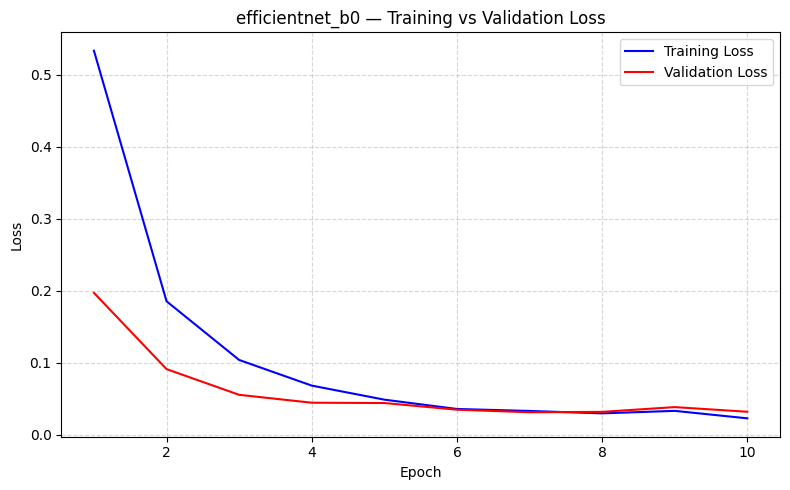

Loaded best model for efficientnet_b0 (Val Loss: 0.0310)

efficientnet_b0 — Test Accuracy: 0.9500
              precision    recall  f1-score   support

      glioma       1.00      0.82      0.90       400
   menigioma       0.90      0.98      0.94       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.99      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600

✅ Saved: efficientnet_b0 | Done so far: ['efficientnet_b0']

Training resnet50
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 134MB/s]
resnet50 Epoch 1/10: 100%|██████████| 123/123 [01:00<00:00,  2.02it/s]


Epoch 1/10 - Avg Loss: 0.3008348796425796
✅ Best model saved (Val Loss = 0.1723)
Epoch 1/10 | Train Loss: 0.3008 | Val Loss: 0.1723 | LR: 1.00e-04


resnet50 Epoch 2/10: 100%|██████████| 123/123 [01:00<00:00,  2.05it/s]


Epoch 2/10 - Avg Loss: 0.10838342205113996
✅ Best model saved (Val Loss = 0.1011)
Epoch 2/10 | Train Loss: 0.1084 | Val Loss: 0.1011 | LR: 1.00e-04


...

Epoch 8/10 - Avg Loss: 0.01880221500069024
✅ Best model saved (Val Loss = 0.0317)
Epoch 8/10 | Train Loss: 0.0188 | Val Loss: 0.0317 | LR: 1.00e-04


resnet50 Epoch 9/10: 100%|██████████| 123/123 [00:59<00:00,  2.05it/s]


Epoch 9/10 - Avg Loss: 0.022653256083471414
✅ Best model saved (Val Loss = 0.0317)
Epoch 9/10 | Train Loss: 0.0227 | Val Loss: 0.0568 | LR: 1.00e-04


resnet50 Epoch 10/10: 100%|██████████| 123/123 [00:59<00:00,  2.07it/s]


Epoch 10/10 - Avg Loss: 0.023707684157397296
✅ Best model saved (Val Loss = 0.0317)
Epoch 10/10 | Train Loss: 0.0237 | Val Loss: 0.0651 | LR: 1.00e-04


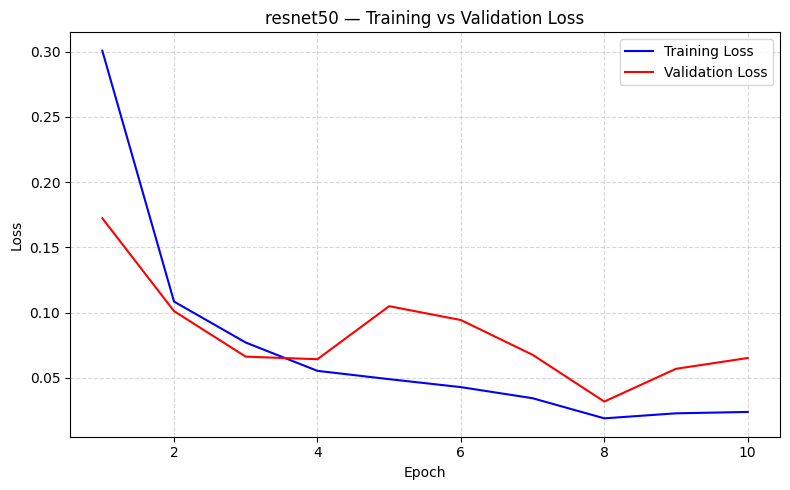

Loaded best model for resnet50 (Val Loss: 0.0317)

resnet50 — Test Accuracy: 0.9513
              precision    recall  f1-score   support

      glioma       1.00      0.82      0.90       400
   menigioma       0.90      0.98      0.94       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.98      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600

✅ Saved: resnet50 | Done so far: ['efficientnet_b0', 'resnet50']

Training vgg16
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 107MB/s]
vgg16 Epoch 1/10: 100%|██████████| 123/123 [01:21<00:00,  1.51it/s]


Epoch 1/10 - Avg Loss: 0.47291726455455874
✅ Best model saved (Val Loss = 0.2093)
Epoch 1/10 | Train Loss: 0.4729 | Val Loss: 0.2093 | LR: 1.00e-04


vgg16 Epoch 2/10: 100%|██████████| 123/123 [01:21<00:00,  1.51it/s]


Epoch 2/10 - Avg Loss: 0.18067466312398514
✅ Best model saved (Val Loss = 0.1652)
Epoch 2/10 | Train Loss: 0.1807 | Val Loss: 0.1652 | LR: 1.00e-04


...

Epoch 8/10 - Avg Loss: 0.020104960290846213
✅ Best model saved (Val Loss = 0.0863)
Epoch 8/10 | Train Loss: 0.0201 | Val Loss: 0.3667 | LR: 1.00e-04


vgg16 Epoch 9/10: 100%|██████████| 123/123 [01:21<00:00,  1.51it/s]


Epoch 9/10 - Avg Loss: 0.05071496278732803
✅ Best model saved (Val Loss = 0.0863)
Epoch 9/10 | Train Loss: 0.0507 | Val Loss: 0.1674 | LR: 5.00e-05


vgg16 Epoch 10/10: 100%|██████████| 123/123 [01:21<00:00,  1.51it/s]


Epoch 10/10 - Avg Loss: 0.021562099880271503
✅ Best model saved (Val Loss = 0.0761)
Epoch 10/10 | Train Loss: 0.0216 | Val Loss: 0.0761 | LR: 5.00e-05


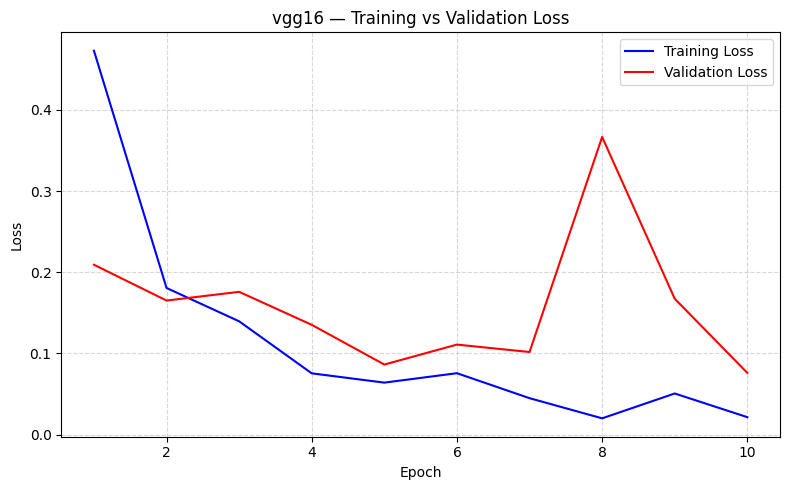

Loaded best model for vgg16 (Val Loss: 0.0761)

vgg16 — Test Accuracy: 0.9463
              precision    recall  f1-score   support

      glioma       0.99      0.82      0.90       400
   menigioma       0.92      0.97      0.94       400
     notumor       0.90      1.00      0.95       400
   pituitary       0.98      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600

✅ Saved: vgg16 | Done so far: ['efficientnet_b0', 'resnet50', 'vgg16']

Training mobilenet_v2
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 196MB/s]
mobilenet_v2 Epoch 1/10: 100%|██████████| 123/123 [00:33<00:00,  3.65it/s]


Epoch 1/10 - Avg Loss: 0.3573738078518612
✅ Best model saved (Val Loss = 0.1718)
Epoch 1/10 | Train Loss: 0.3574 | Val Loss: 0.1718 | LR: 1.00e-04


mobilenet_v2 Epoch 2/10: 100%|██████████| 123/123 [00:33<00:00,  3.68it/s]


Epoch 2/10 - Avg Loss: 0.12138257065136743
✅ Best model saved (Val Loss = 0.0798)
Epoch 2/10 | Train Loss: 0.1214 | Val Loss: 0.0798 | LR: 1.00e-04


...

Epoch 8/10 - Avg Loss: 0.03285061765998806
✅ Best model saved (Val Loss = 0.0503)
Epoch 8/10 | Train Loss: 0.0329 | Val Loss: 0.0587 | LR: 1.00e-04


mobilenet_v2 Epoch 9/10: 100%|██████████| 123/123 [00:32<00:00,  3.76it/s]


Epoch 9/10 - Avg Loss: 0.02855157403879216
✅ Best model saved (Val Loss = 0.0503)
Epoch 9/10 | Train Loss: 0.0286 | Val Loss: 0.0630 | LR: 1.00e-04


mobilenet_v2 Epoch 10/10: 100%|██████████| 123/123 [00:32<00:00,  3.83it/s]


Epoch 10/10 - Avg Loss: 0.03149479902179048
✅ Best model saved (Val Loss = 0.0503)
Epoch 10/10 | Train Loss: 0.0315 | Val Loss: 0.0624 | LR: 5.00e-05


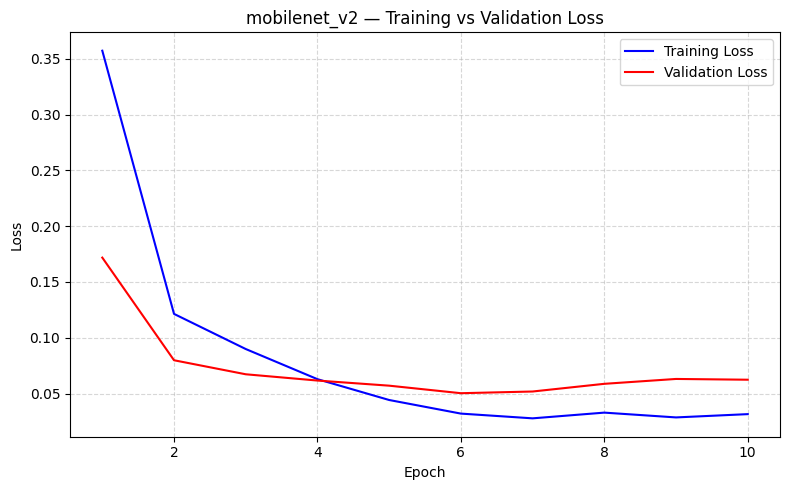

Loaded best model for mobilenet_v2 (Val Loss: 0.0503)

mobilenet_v2 — Test Accuracy: 0.9463
              precision    recall  f1-score   support

      glioma       1.00      0.82      0.90       400
   menigioma       0.91      0.96      0.94       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.97      1.00      0.98       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600

✅ Saved: mobilenet_v2 | Done so far: ['efficientnet_b0', 'resnet50', 'vgg16', 'mobilenet_v2']

Training densenet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 181MB/s]
densenet121 Epoch 1/10: 100%|██████████| 123/123 [00:57<00:00,  2.15it/s]


Epoch 1/10 - Avg Loss: 0.33595972814089886
✅ Best model saved (Val Loss = 0.1085)
Epoch 1/10 | Train Loss: 0.3360 | Val Loss: 0.1085 | LR: 1.00e-04


densenet121 Epoch 2/10: 100%|██████████| 123/123 [00:57<00:00,  2.16it/s]


Epoch 2/10 - Avg Loss: 0.10124472252327979
✅ Best model saved (Val Loss = 0.0919)
Epoch 2/10 | Train Loss: 0.1012 | Val Loss: 0.0919 | LR: 1.00e-04


...

Epoch 8/10 - Avg Loss: 0.02450155193124315
✅ Best model saved (Val Loss = 0.0329)
Epoch 8/10 | Train Loss: 0.0245 | Val Loss: 0.0390 | LR: 1.00e-04


densenet121 Epoch 9/10: 100%|██████████| 123/123 [00:58<00:00,  2.11it/s]


Epoch 9/10 - Avg Loss: 0.019770944812827235
✅ Best model saved (Val Loss = 0.0329)
Epoch 9/10 | Train Loss: 0.0198 | Val Loss: 0.0459 | LR: 1.00e-04


densenet121 Epoch 10/10: 100%|██████████| 123/123 [00:58<00:00,  2.10it/s]


Epoch 10/10 - Avg Loss: 0.012376779892455362
✅ Best model saved (Val Loss = 0.0329)
Epoch 10/10 | Train Loss: 0.0124 | Val Loss: 0.0365 | LR: 5.00e-05


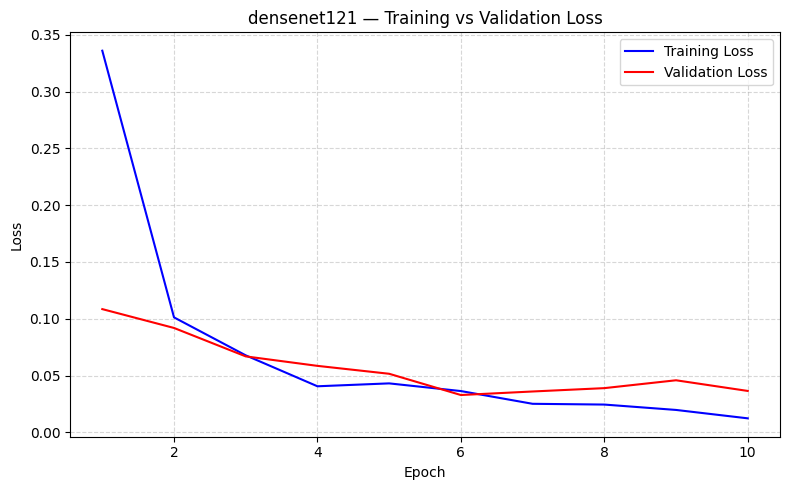

Loaded best model for densenet121 (Val Loss: 0.0329)

densenet121 — Test Accuracy: 0.9531
              precision    recall  f1-score   support

      glioma       1.00      0.83      0.91       400
   menigioma       0.91      0.98      0.95       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.99      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.96      0.95      0.95      1600
weighted avg       0.96      0.95      0.95      1600

✅ Saved: densenet121 | Done so far: ['efficientnet_b0', 'resnet50', 'vgg16', 'mobilenet_v2', 'densenet121']

Training alexnet
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 177MB/s]
alexnet Epoch 1/10: 100%|██████████| 123/123 [00:25<00:00,  4.85it/s]


Epoch 1/10 - Avg Loss: 0.45074515559566697
✅ Best model saved (Val Loss = 0.2510)
Epoch 1/10 | Train Loss: 0.4507 | Val Loss: 0.2510 | LR: 1.00e-04


alexnet Epoch 2/10: 100%|██████████| 123/123 [00:25<00:00,  4.85it/s]


Epoch 2/10 - Avg Loss: 0.22507885537617575
✅ Best model saved (Val Loss = 0.2025)
Epoch 2/10 | Train Loss: 0.2251 | Val Loss: 0.2025 | LR: 1.00e-04


...

Epoch 8/10 - Avg Loss: 0.06230361574344579
✅ Best model saved (Val Loss = 0.1566)
Epoch 8/10 | Train Loss: 0.0623 | Val Loss: 0.1863 | LR: 1.00e-04


alexnet Epoch 9/10: 100%|██████████| 123/123 [00:25<00:00,  4.81it/s]


Epoch 9/10 - Avg Loss: 0.05944795870625346
✅ Best model saved (Val Loss = 0.1407)
Epoch 9/10 | Train Loss: 0.0594 | Val Loss: 0.1407 | LR: 1.00e-04


alexnet Epoch 10/10: 100%|██████████| 123/123 [00:25<00:00,  4.80it/s]


Epoch 10/10 - Avg Loss: 0.04559232849519836
✅ Best model saved (Val Loss = 0.1407)
Epoch 10/10 | Train Loss: 0.0456 | Val Loss: 0.1501 | LR: 1.00e-04


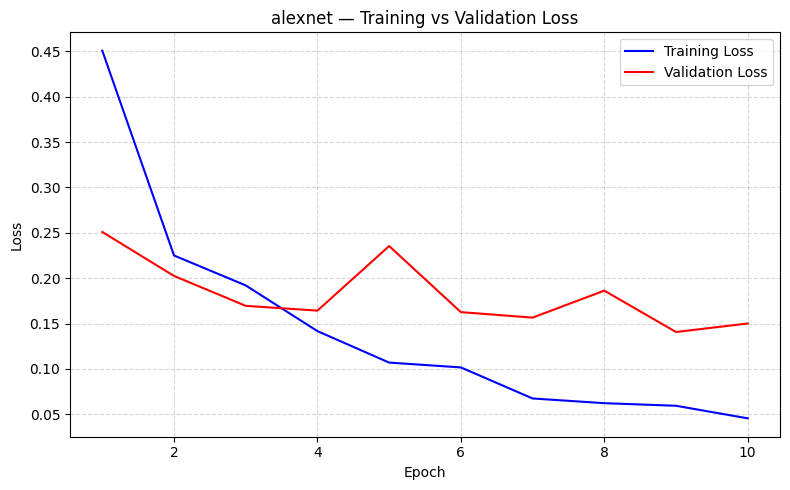

Loaded best model for alexnet (Val Loss: 0.1407)

alexnet — Test Accuracy: 0.9231
              precision    recall  f1-score   support

      glioma       0.99      0.75      0.86       400
   menigioma       0.85      0.94      0.89       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.95      0.99      0.97       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600

✅ Saved: alexnet | Done so far: ['efficientnet_b0', 'resnet50', 'vgg16', 'mobilenet_v2', 'densenet121', 'alexnet']

✅ ALL ARCHITECTURES DONE


In [ ]:
import json
results = {}
if os.path.exists("results_backup.json"):
  with open("results_backup.json", "r") as f:
    results = json.load(f)
  print("Loaded existing results:", list(results.keys()))
else:
  print("Starting fresh")


loss_fn = nn.CrossEntropyLoss()
params = {
    "batch_size" : 32,
    "learning_rate" : 1e-4,
    "num_epochs" : 10
}

architectures = [
    "efficientnet_b0",
    "resnet50",
    "vgg16",
    "mobilenet_v2",
    "densenet121",
    "alexnet"
]
for arch_name in architectures:
  if arch_name in results:
    print(f"{arch_name} already saved")
    continue

  print(f"\n{"=" * 50}")
  print(f"Training {arch_name}")
  print("=" * 50)

  standard_classifier = make_pretrained_classifier(arch_name, n_outputs=4)
  optimizer = optim.Adam(standard_classifier.parameters(), lr=params["learning_rate"])
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
      optimizer, mode="min", factor = 0.5, patience=3, min_lr = 1e-7
  )
  patience = 5
  best_val_loss = float("inf")
  counter = 0


  # TRAINING
  train_losses, val_losses = [],[]
  best_loss = float("inf")
  for epoch in range(params["num_epochs"]):
    standard_classifier.train()
    epoch_train_loss = 0.0

    for x,y in tqdm(train_loader, desc=f"{arch_name} Epoch {epoch+1}/{params["num_epochs"]}"):
      x = x.float().to(device)
      y = y.long().to(device)
      optimizer.zero_grad()
      logits = standard_classifier(x)
      loss = loss_fn(logits, y)
      loss.backward()
      optimizer.step()
      epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss/len(train_loader)
    print(f"Epoch {epoch+1}/{params["num_epochs"]} - Avg Loss: {avg_train_loss}")

    # Validation
    standard_classifier.eval()
    epoch_val_loss = 0.0

    with torch.inference_mode():
      for x,y in val_loader:
        x = x.float().to(device)
        y = y.long().to(device)
        logits = standard_classifier(x)
        loss = loss_fn(logits, y)
        epoch_val_loss += loss.item()



    avg_val_loss = epoch_val_loss/len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)
    if avg_val_loss < best_loss:
      best_loss = avg_val_loss
      counter = 0
      torch.save(standard_classifier.state_dict(), f"{arch_name}_best.pth")
    else:
      counter += 1
    if counter >= patience:
      print("Early stopping triggered")
      break

    print(f"✅ Best model saved (Val Loss = {best_loss:.4f})")
    print(
    f"Epoch {epoch+1}/{params['num_epochs']} | "
    f"Train Loss: {avg_train_loss:.4f} | "
    f"Val Loss: {avg_val_loss:.4f} | "
    f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, len(train_losses)+1), train_losses, label="Training Loss",   color="blue")
  plt.plot(range(1, len(val_losses)+1),   val_losses,   label="Validation Loss", color="red")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title(f"{arch_name} — Training vs Validation Loss")
  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.5)
  plt.tight_layout()
  plt.show()

  # EVALUATION
  standard_classifier.load_state_dict(torch.load(f"{arch_name}_best.pth"))
  standard_classifier = standard_classifier.to(device)
  print(f"Loaded best model for {arch_name} (Val Loss: {best_loss:.4f})")
  standard_classifier.eval()
  all_preds, all_labels = [],[]
  with torch.inference_mode():
    for x,y in test_loader:
      x = x.float().to(device)
      logits = standard_classifier(x)
      probs = torch.softmax(logits, dim=1)
      preds = torch.argmax(probs, dim=1)
      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(y.numpy())

  all_preds = np.array(all_preds)
  all_labels = np.array(all_labels)

  report = classification_report(
      all_labels, all_preds,
      target_names=["glioma", "menigioma", "notumor", "pituitary"],
      output_dict=True
  )

  print(f"\n{arch_name} — Test Accuracy: {report['accuracy']:.4f}")
  print(classification_report(all_labels, all_preds, target_names=["glioma", "menigioma", "notumor", "pituitary"]))

  # ── SAVE ──────────────────────────────────────────────
  results[arch_name] = {
    "Accuracy": round(report["accuracy"], 4),

    "Glioma Precision": round(report["glioma"]["precision"], 4),
    "Glioma Recall": round(report["glioma"]["recall"], 4),

    "Menigioma Precision": round(report["menigioma"]["precision"], 4),
    "Meningioma Recall": round(report["menigioma"]["recall"], 4),

    "No Tumor Precision": round(report["notumor"]["precision"], 4),
    "No Tumor Recall": round(report["notumor"]["recall"], 4),

    "Pituitary Precision": round(report["pituitary"]["precision"], 4),
    "Pituitary Recall": round(report["pituitary"]["recall"], 4),

    "Macro F1": round(report["macro avg"]["f1-score"], 4),
  }


  with open("results_backup.json", "w") as f:
      json.dump(results, f)
  print(f"✅ Saved: {arch_name} | Done so far: {list(results.keys())}")

  del standard_classifier, optimizer, scheduler
  torch.cuda.empty_cache()

print("\n✅ ALL ARCHITECTURES DONE")